In [2]:
import numpy as np
import pandas as pd
import scipy
import random
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from math import pi
from scipy.interpolate import NearestNDInterpolator

%matplotlib inline


#floris simulation modules
from floris.tools.wind_rose import WindRose
from floris.tools import FlorisInterface
import floris.tools.visualization as wakeviz
from floris.tools.layout_functions import visualize_layout
from floris.turbine_library import TurbineInterface, TurbineLibrary
from floris.tools.visualization import (
    calculate_horizontal_plane_with_turbines,
    visualize_cut_plane,
)

In [3]:
df_wind_montly = pd.read_csv('../2020_Daily_Avgs.csv')
df_wind_montly.head()

list_wd_bins = [0., 5., 10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60., 65., 70., 75., 80., 85., 90., 95., 100., 105., 110., 115., 120., 125., 130., 135., 140., 145., 150., 155., 160., 165., 170., 175., 180., 185., 190., 195., 200., 205., 210., 215., 220., 225., 230., 235., 240., 245., 250., 255., 260., 265., 270., 275., 280., 285., 290., 295., 300., 305., 310., 315., 320., 325., 330., 335., 340., 345., 350., 355.]

list_ws_bins = [0., 1., 2., 3., 4., 5., 6., 7., 8., 9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.]

windr = WindRose()

df_wind_calc = windr.make_wind_rose_from_user_data(wd_raw=df_wind_montly['average_wind_dir_deg'], ws_raw=df_wind_montly['Factorized_Mean'], wd=np.array(list_wd_bins), ws=np.array(list_ws_bins))


wd_array = np.array(df_wind_calc["wd"].unique(), dtype=float)
ws_array = np.array(df_wind_calc["ws"].unique(), dtype=float)


wd_grid, ws_grid = np.meshgrid(wd_array, ws_array, indexing="ij")
freq_interp = NearestNDInterpolator(df_wind_calc[["wd", "ws"]], df_wind_calc["freq_val"])
freq = freq_interp(wd_grid, ws_grid)

# Normalize the frequency array to sum to exactly 1.0
freq = freq / np.sum(freq)

Correcting negative Overhang:-2.5


In [4]:
df_vestas = pd.read_csv('../pop_fav.csv')
df_nrel = pd.read_csv('../gen_2_13.csv')

In [11]:
list_x = list(df_vestas['Layout_y'])
list_x

[1968.4143310612676,
 1925.343742384362,
 1879.2237910900344,
 1836.0397829664932,
 1786.2146709059016,
 1747.2868941817671,
 1700.7294810925675,
 1658.8735307004915,
 1612.6221592313082,
 1563.55042856672,
 1525.388296605856,
 1466.9473290222884,
 1427.8971765359574,
 1383.0131673425062,
 1332.3614363938036,
 1295.9543024527447,
 1248.558061175904,
 1211.4089538992534,
 1164.4113069237028,
 1115.752500017664,
 1068.344662361622,
 1026.992669196865,
 986.613967185716,
 930.0394336502038,
 890.7093551452276,
 848.6486510238424,
 799.8531695673018,
 761.9432174951442,
 705.6136458305434,
 668.5015255551923,
 614.0182670195427,
 582.6055260978089,
 534.3343729744945,
 491.27397863278657,
 445.20829920682377,
 398.4911821301139,
 356.5656401620947,
 319.8878227163982,
 272.63552521913994,
 220.8233962939605,
 183.21166275489625,
 136.3536785010217,
 85.20301158307461,
 39.480785005716825,
 0.0]

In [12]:
fi_powers_vestas = FlorisInterface('./vestas_jensen.yaml')

In [13]:
def aep_powers(fi, wind_shear):
    power_list = []
    fi.reinitialize(
        wind_directions=wd_array,
        wind_speeds=ws_array,
        wind_shear=wind_shear,
    )

    aep = fi.get_farm_AEP(
        freq=freq,
        cut_in_wind_speed=4.0,  # Wakes are not evaluated below this wind speed
        cut_out_wind_speed=25.0,  # Wakes are not evaluated above this wind speed
    )
    power_list.append(round((aep / 1.0e9), 3))

    aep_no_wake = fi.get_farm_AEP(freq, no_wake=True)
    power_list.append(round((aep_no_wake / 1.0e9), 3))

    percentage_power_loss = (aep_no_wake - aep) / aep_no_wake * 100
    power_list.append(round(percentage_power_loss, 3))


    return power_list

In [20]:
fi_powers_nrel = FlorisInterface('./nrel_jensen.yaml')

In [10]:
power_loss_90_110 = []
p_with_w_90_110 = []
p_without_w_90_110 = []

In [11]:
for i in np.arange(0.16, 0.37, 0.02):
    power_p = aep_powers(fi_powers_nrel, i)
    power_loss_90_110.append(power_p[2])
    p_with_w_90_110.append(power_p[0])
    p_without_w_90_110.append(power_p[1])

In [13]:
power_loss_90_115 = []
p_with_w_90_115 = []
p_without_w_90_115 = []

In [14]:
for i in np.arange(0.16, 0.37, 0.02):
    power_p = aep_powers(fi_powers_nrel, i)
    power_loss_90_115.append(power_p[2])
    p_with_w_90_115.append(power_p[0])
    p_without_w_90_115.append(power_p[1])


In [18]:
power_loss_90_125 = []
p_with_w_90_125 = []
p_without_w_90_125 = [] 

In [19]:
for i in np.arange(0.16, 0.37, 0.02):
    power_p = aep_powers(fi_powers_nrel, i)
    power_loss_90_125.append(power_p[2])
    p_with_w_90_125.append(power_p[0])
    p_without_w_90_125.append(power_p[1])

In [23]:
power_loss_90 = []
p_with_w_90 = []
p_without_w_90 = [] 

In [24]:
for i in np.arange(0.16, 0.37, 0.02):
    power_p = aep_powers(fi_powers_nrel, i)
    power_loss_90.append(power_p[2])
    p_with_w_90.append(power_p[0])
    p_without_w_90.append(power_p[1])

In [ ]:
fi_powers_vestas = FlorisInterface('./vestas_jensen.yaml')

In [19]:
aep_powers(fi_powers_vestas, 0.12)

floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.


[77.289, 92.789, 16.705]

In [31]:
x_axis = np.arange(0.16, 0.37, 0.02)

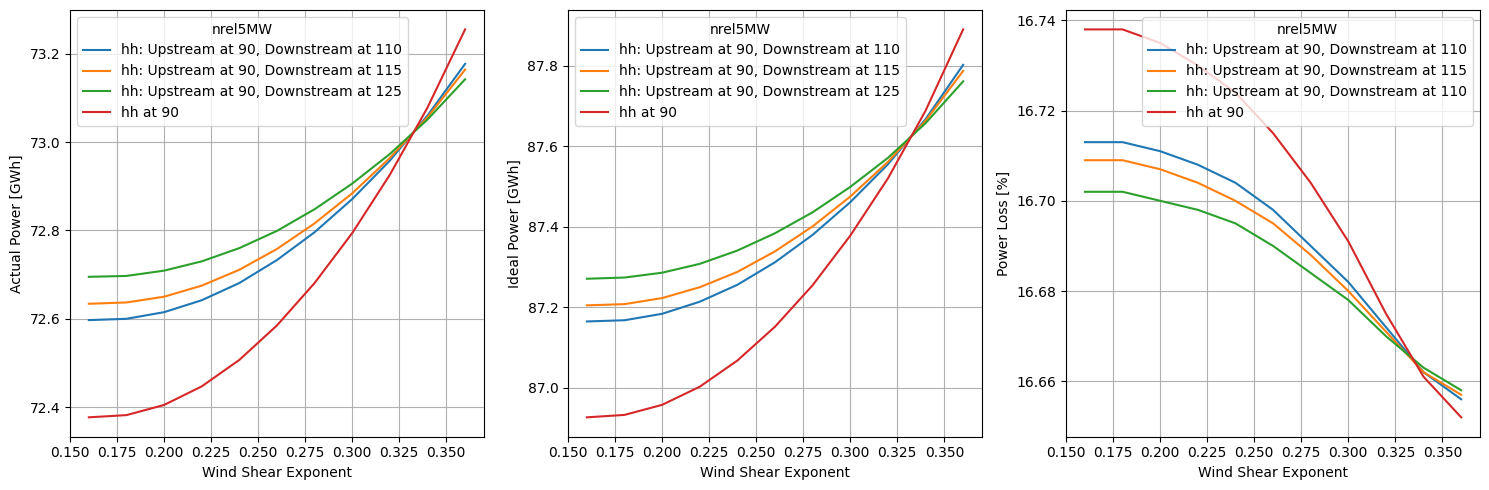

In [29]:
fig, axarr = plt.subplots(1, 3, figsize=(15, 5))

# Plot Actual Power
ax = axarr[0]
ax.plot(x_axis, p_with_w_90_110, label='hh: Upstream at 90, Downstream at 110')
ax.plot(x_axis, p_with_w_90_115, label='hh: Upstream at 90, Downstream at 115')
ax.plot(x_axis, p_with_w_90_125, label='hh: Upstream at 90, Downstream at 125')
ax.plot(x_axis, p_with_w_90, label='hh at 90')
ax.set_xlabel('Wind Shear Exponent')
ax.set_ylabel('Actual Power [GWh]')
ax.legend(title="nrel5MW",)
ax.grid()
# Plot Ideal Power
ax = axarr[1]
ax.plot(x_axis, p_without_w_90_110, label='hh: Upstream at 90, Downstream at 110')
ax.plot(x_axis, p_without_w_90_115, label='hh: Upstream at 90, Downstream at 115')
ax.plot(x_axis, p_without_w_90_125, label='hh: Upstream at 90, Downstream at 125')
ax.plot(x_axis, p_without_w_90, label='hh at 90')
ax.set_xlabel('Wind Shear Exponent')
ax.set_ylabel('Ideal Power [GWh]')
ax.legend(title="nrel5MW",)
ax.grid()

# Plot Power Loss
ax = axarr[2]
ax.plot(x_axis, power_loss_90_110, label='hh: Upstream at 90, Downstream at 110')
ax.plot(x_axis, power_loss_90_115, label='hh: Upstream at 90, Downstream at 115')
ax.plot(x_axis, power_loss_90_125, label='hh: Upstream at 90, Downstream at 110')
ax.plot(x_axis, power_loss_90, label='hh at 90')
ax.set_xlabel('Wind Shear Exponent')
ax.set_ylabel('Power Loss [%]')
ax.legend(
    title="nrel5MW",
)
ax.grid()

plt.tight_layout()

plt.show()

In [14]:
power_loss_48 = []
p_with_w_48 = []
p_without_w_48 = [] 

In [21]:
power_loss_45_55 = []
p_with_w_45_55 = []
p_without_w_45_55 = [] 

In [22]:
power_loss_45_65 = []
p_with_w_45_65 = []
p_without_w_45_65 = [] 

In [23]:
power_loss_45_75 = []
p_with_w_45_75 = []
p_without_w_45_75 = [] 

In [16]:
for i in np.arange(0.16, 0.37, 0.02):
    power_p = aep_powers(fi_powers_vestas, i)
    power_loss_48.append(power_p[2])
    p_with_w_48.append(power_p[0])
    p_without_w_48.append(power_p[1])

floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.


In [24]:
fi_powers_vestas = FlorisInterface('./vestas_jensen.yaml')

In [25]:
for i in np.arange(0.16, 0.37, 0.02):
    power_p = aep_powers(fi_powers_vestas, i)
    power_loss_45_55.append(power_p[2])
    p_with_w_45_55.append(power_p[0])
    p_without_w_45_55.append(power_p[1])

floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.


In [26]:
fi_powers_vestas = FlorisInterface('./vestas_jensen.yaml')

In [27]:
for i in np.arange(0.16, 0.37, 0.02):
    power_p = aep_powers(fi_powers_vestas, i)
    power_loss_45_65.append(power_p[2])
    p_with_w_45_65.append(power_p[0])
    p_without_w_45_65.append(power_p[1])

floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.


In [28]:
fi_powers_vestas = FlorisInterface('./vestas_jensen.yaml')

In [29]:
for i in np.arange(0.16, 0.37, 0.02):
    power_p = aep_powers(fi_powers_vestas, i)
    power_loss_45_75.append(power_p[2])
    p_with_w_45_75.append(power_p[0])
    p_without_w_45_75.append(power_p[1])

floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.


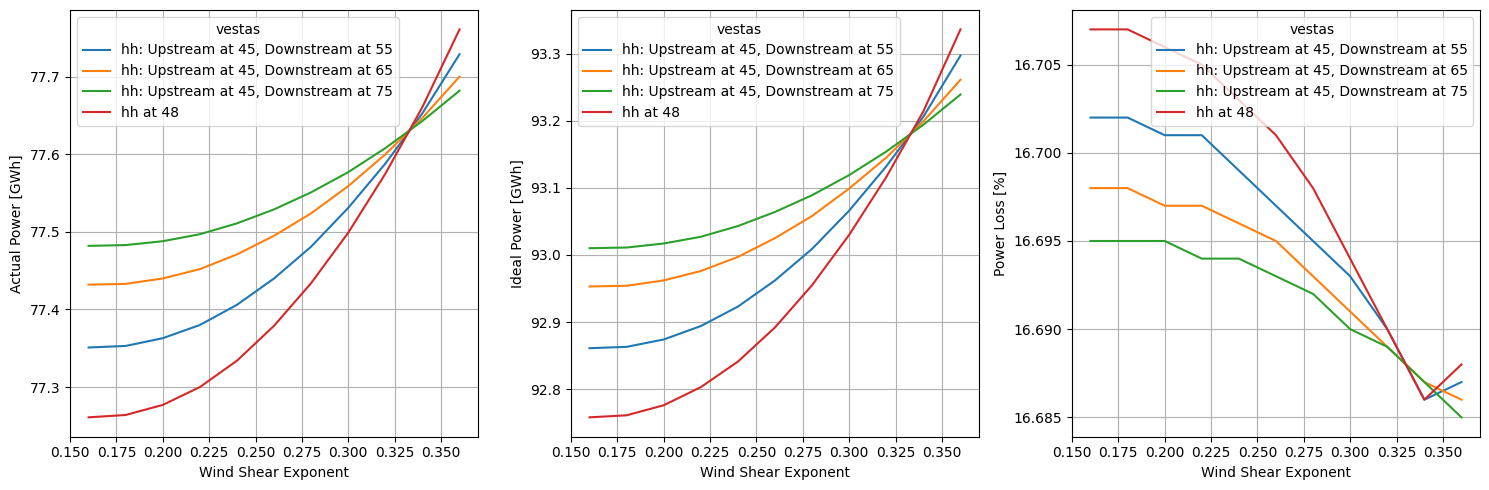

In [33]:
fig, axarr = plt.subplots(1, 3, figsize=(15, 5))

# Plot Actual Power
ax = axarr[0]
ax.plot(x_axis, p_with_w_45_55, label='hh: Upstream at 45, Downstream at 55')
ax.plot(x_axis, p_with_w_45_65, label='hh: Upstream at 45, Downstream at 65')
ax.plot(x_axis, p_with_w_45_75, label='hh: Upstream at 45, Downstream at 75')
ax.plot(x_axis, p_with_w_48, label='hh at 48')
ax.set_xlabel('Wind Shear Exponent')
ax.set_ylabel('Actual Power [GWh]')
ax.legend(title="vestas",)
ax.grid()
# Plot Ideal Power
ax = axarr[1]
ax.plot(x_axis, p_without_w_45_55, label='hh: Upstream at 45, Downstream at 55')
ax.plot(x_axis, p_without_w_45_65, label='hh: Upstream at 45, Downstream at 65')
ax.plot(x_axis, p_without_w_45_75, label='hh: Upstream at 45, Downstream at 75')
ax.plot(x_axis, p_without_w_48, label='hh at 48')
ax.set_xlabel('Wind Shear Exponent')
ax.set_ylabel('Ideal Power [GWh]')
ax.legend(title="vestas",)
ax.grid()

# Plot Power Loss
ax = axarr[2]
ax.plot(x_axis, power_loss_45_55, label='hh: Upstream at 45, Downstream at 55')
ax.plot(x_axis, power_loss_45_65, label='hh: Upstream at 45, Downstream at 65')
ax.plot(x_axis, power_loss_45_75, label='hh: Upstream at 45, Downstream at 75')
ax.plot(x_axis, power_loss_48, label='hh at 48')
ax.set_xlabel('Wind Shear Exponent')
ax.set_ylabel('Power Loss [%]')
ax.legend(
    title="vestas",
)
ax.grid()

plt.tight_layout()

plt.show()